# accDM: compare three selected one-loop fits

Na każdym wykresie są **trzy krzywe one-loop** i wspólne dane BOSS DR12:

1. **Minimum χ²:** najniższa odtwarzalna zapisana χ² spośród dostępnych punktów indeksu (całe 1600 punktów, jeżeli ich pliki są dostępne), z uwzględnieniem poprzednich 30 poprawek i wyników Stage A, także z trwającej rundy.
2. **Peak region:** najbliższy dostępny punkt względem `PEAK_TARGET = (12.7, -0.1)`, z jego najlepszym odtwarzalnym zapisanym fitem nuisance. Nie wybieramy tu maksimum χ²; wskazana okolica wyznacza model do porównania.
3. **Your point:** najbliższy dostępny punkt względem `USER_TARGET`, ustawianego przez Ciebie.

Współrzędne to `(log10(m/GeV), log10(f))`. Odległość do sąsiada liczymy w tej przestrzeni, ze skalami `NEAREST_SCALES`. Tabela podaje rzeczywiste współrzędne, odchylenie od zapytania, χ² i źródło wyniku. χ² jest dla całego dopasowanego zestawu danych, niezależnie od wyświetlanych redshiftów.

**Użycie:** sprawdź `PROJECT_ROOT`, wybierz `USER_TARGET` i uruchom komórki od góry. Domyślnie `REDSHIFTS=[3.0]` daje jeden wykres z trzema liniami. `REDSHIFTS=None` daje osobny panel dla każdego redshiftu, zawsze z trzema modelami. Po zmianie ustawień ponów komórkę ustawień i ostatnią komórkę `comparison = compare_three_points()`.

Nie wykonujemy nowych fitów ani CLASS. Odczytujemy metadane siatki i odtwarzamy widma tylko potrzebnych kandydatów. Trwająca kampania może zmienić znaleziony punkt minimum po kolejnym odświeżeniu. **To minimum dostępnych zapisanych wyników, nie certyfikat minimum globalnego.** Jeśli dwa wybory wskazują ten sam punkt, notebook zgłasza nakładanie krzywych i nie podmienia go po cichu.

Potrzebne są: `lyalpha_pt/`, dane DR12, oryginalne JSON fitów i odpowiadające im NPZ. Dodatkowo `stage_A/` zawiera najnowsze nuisance. Sam CSV monitora nie wystarcza do odtworzenia widm. Brakujące lokalnie punkty są wyłączone z wyboru; zasięg wyszukiwania jest wypisywany. Dane DR12 i modele nie są wygładzane.


In [50]:
from pathlib import Path
from datetime import datetime
import base64, gzip, io, json, warnings, hashlib, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root():
    here=Path.cwd().resolve()
    for p in [here,*here.parents,Path('/home/2/ks405818/Master/lyalpha_one_loop'),
              Path('/home/krzysztof/Workspace/lyalpha_one_loop')]:
        if (p/'lyalpha_pt').is_dir(): return p
    return here

PROJECT_ROOT=find_project_root()
# PROJECT_ROOT=Path('/home/2/ks405818/Master/lyalpha_one_loop')
RUN_DIR=PROJECT_ROOT/'runs/accdm/reprofile_upper_v2/stage_A'
DATA_DIR=None
PATH_REMAP={}
SCAN_ROOTS=[]  # optional new campaigns with manifest.csv, fits/, theory/
EXPORT_DIR=PROJECT_ROOT/'runs/accdm/three_point_p1d_figures'

PEAK_TARGET=(12.7, -0.1)
USER_TARGET=(13.73, -0.8)  # <-- choose your third point here
NEAREST_SCALES=(1.0, 1.0)  # distances in log10 mass and log10 fraction

REDSHIFTS=[3.0, 3.2, 3.4, 3.6, 3.8, 4.0, 4.2]  # one plot with 3 model curves; None = panels for all redshifts
DIVIDE_BY_PI=False
XSCALE, YSCALE='linear','linear'
XLIM=(0.015,0.0205)
YLIM=(1e-1, 1.0)
SHOW_TITLE=True
SAVE_OUTPUTS=False  # PNG + PDF + selected-point CSV + curve CSV + metadata JSON
CHI2_ATOL, CHI2_RTOL=1e-5,1e-8
plt.rcParams.update({'font.size':11,'figure.dpi':110})
print('Project:',PROJECT_ROOT)
print('Updates:',RUN_DIR)


Project: /home/2/ks405818/Master/lyalpha_one_loop
Updates: /home/2/ks405818/Master/lyalpha_one_loop/runs/accdm/reprofile_upper_v2/stage_A


## Helper functions

Osadzony indeks zawiera oryginalne ścieżki 1600 punktów. Przy zachowaniu struktury projektu ścieżki z klastra są automatycznie przenoszone pod `PROJECT_ROOT`. Do niestandardowego układu katalogów użyj `PATH_REMAP`.


In [51]:
_BASELINE_GZIP = '...'
_SEEDS_GZIP = 'H4sIAAAAAAACA6WcaXIbSZKF//dZIFjsywXmGrRcIqtkoyrJKFb3zNgcfr4XIMXcWAOwZUYKfEBmxvLC/bmHB16G59/ay+Xb99+s+eNpmKbby6W/nH7/6p6+f5tvL8b28+Xy2/D1z9ufz21pz+3PqV3m9u1lePr14dWf/ZKf7VubXtr89P35629c/c/h29d5ePn6/c+nny/Dy18/L99/vHz94+v/bLDh5aX98ePl52X8a6aFT+2/fh/++slt3j7dnp9+/jVN7efP9vPy8nv7/vzfT/PX3/TEH8Pz8Ed74RO054kOPQ3ffvw+PP3H6h01bfPWt+//Al4jf/34sUO2Nx7by8k9X9Hb7V7/uN3p8Hnd5Hbr8evwc3+j1Tu3m62A2w1Pr/3VsrN7vr+xat/qjmcXvrdyejlv4/SyaSF/rts3vZy17nivN3jVsl93evurs2r5/vyv4fmNlcP0n/2v+eszNOsM+vHchvkCkcav376+/PfTII78/KP9+XIZfntuTa+eXr5/a88D/P2HDddsgyuR3/5/v9irz9Hc/l02711u712cK9fi+VesTyHF6C+22msNLtXoizOlhnjx6VqqScHlGHxOJoeLLeUaXI01h5SM5dUlmGswPgeTsgnRxXLx12i9qblarkmRN1eU/+fXn1+1CF4XEa+m73/8+Na0vn4tmXIx/JR5HgeaGV3LIS8xjuPsS01psnW2c3U1D2UeTBqdiYuPNi3DkGIxxcaWQrh8CdeY6E7x1ngTjS0dsoZ70N9Mb2tlTCyYqy6GFGo2ztWLuabqbci2mBgrg+Ev8ZoZr8wQpRx85V7xanxwDF5kaHkCD7Tmai5Ov774q48MB2NZQrU+FEE0uYTiGScGJsXLl8JH9WO5l/M+0TjGzJTEWF+Dpem5MvY1R8vd49vd3ZWWR+5Qq6E71ob2peTLF96jbdHxzOSY8RicJh0i6Bm3/77Qh6t3DJT1/LhULgApBsscJq5kAPfXbNkBKU4Qfe6dnd/Hn+35n0zqn99fnn779n0cvj39eP7+fdHn7D/UlV//9pRVN9+Y6u3VhWjgVi2e7kae7K/MUsoMo0nG1XTx+aqeMnkh58isnhLVXSFGyF4jHTLT53idYy0hVp5bPsdS1+bJ+rHVNgxtTIFVFaec5xLcsDg72iH7mbeHoY7BjyyJ2YdqYp3rNFpjbyyN0I1m1QK9YrzRFMqquZZeO/sATV2EM8Umm0uqTjR1zkcTsyaL5bynafKVeSw5JQ87O2SiczTS2ZKyZW7XPHUBboVSa7IpQy94akq2lvWVk7XGrYnK52mbsxgIVwK3LCuilloYdp9yzXTshKfp6r0JIRibaFK6hHBVRxK9zq4Yf8LTDTdY/WfQY0yt15v11O//ZWLeeXvZvKdJu7XAeQYvW4aU+TsgiYGMLD8Wt6vWWWdc+2LPbeu1GMdIZ+9ysNmnHYJxjZ9j7TxOk3i0MC9Ljq1FO7YxQrbUZviLfbAZRjU/YVpN9MNo4lhsnaKdYuusZU5oiYXKLpm0gZJPjjm6n7Q3kvOapRlDPUG2pGU+Md+5YH6xsPEUeudsgOPFZHoUsADen0Er0nZ2siqgXcR4Y5iy34Ax41JKTN3iv9KP375e4Xi2HrbbGjD5b0j8hWwuOFLjiDxG1q0SMFe7IutWCfDexUXah4OiLzI1OV+cRgGvFeXstFz7oqO7MUFVrERi9Z4wNctcV+espEMKGbuYrrHKsJXsuHW1jxLVWpjKr6HV5CcsRB7wc3aYfR3nBcszjiKZNW1udTZpqXGs4zJghorkylSyH4wbxQ1o7cUMl42vGOhu5GyV2cd4eWPv52rAH9nkDLIm46rLTe8wVBlPyFV5Z2ANugHzUxjnYLoD4q6MdpJhk8/3RUb3jaxfKsaBDhSNecC1ywrg/uSkmDtG09Y1V/lBaqVQ4BePgdGyigY7WXurLHeLZse7LxYFUGKBYfgD+hLlJnLgGYWr0B20M26vWTEjWJRe2SEJNYAu8cnCeAxGwpFlj2WzD9A3bVQBvVjRN91Gkxmg9Rlnz5gmpy6fIL3dR5ri1Zh3GGJ9TaJlOIPGgZDv65/t7/kZoSeTU8w0Dw1LitFp+EXfytiS8UubS15K5c9pmhZ8/dwCVKaVzrmx2TAsJs1iYkHcYBxiF+S5nkL3krPI02bEkjO5amgOyJqcDBuroiAPYoJdNp9Cb9xE6TO6+H/vu6Jl8ZxiG3ri4OTjEssDcsGxU2zv++21oGJxeQgK/EAn4wm0ueheXjxCxzeD6eqRju/vvfIyMhjojKqwouACwwWBjaeBfqgxBSD1Up2UfvYYi8pawbGc0TTpUxhNBBvrlHbbrIWOgEGl40ZKfdjv40n4aYQL6C0Mfy1TmeMyzGGcaGFzuTW1KLnYMDy5LiOdwd7yQeItU8aK5hI3ies8FiLAKjom14mFQvdVXD/OFAcQ7uerxZcyDBiUxFtB1o7uGeQkT0GqV7uzplyGOiHcItBLRnz2XIGlJODBO0GMlVy9MZGLsIGQXzY4hX7RxoLGCKdQAshXHEUUTRzGGpPGo5BbuJ2dq/+Sr/QrcBmTos8kERQTmFm53CG43uWtPFiRQezH52wghk7rFZnOJBA+BMfKd+FhE7qWq3vOruWqOIucpiNIGXQ2cggYZXotKFMmmLCaSb4UtQlHQatYsDacCgDeZFkTnUdsh+GT4ZKzJktRDc4ExuTPUXZ2ieCqzDVOYcLMTB7C+qHlOORpcnlZPCZuXPLimnFT88NCUythl8HE5rEHUyw9g+/MAQftulR1GDmcsUtYWS3DOxnrWOJ41YycyKxCNAZTRkDiCGMQwXDfbLQquohA3UvOOV9Sj1lYLoqcEPIoW8PIvBNWlp8BxA1Zy+hm6T/HR3rgQi+UTck7rYofxvPDYUL3pGZ1+nrPwyTDsbJyajtnjn0xBJtaFokIGrNvK8sJPUKzNCY7ybChRWWi/R4ipqW31idWIY1ELdJqCQD/EHvfjGpJR/a+v3djrxQI6501xwpE1pUT5CMlkK74EluwYU7rN5Yz6BElgMrKkj3NLhPhVFxmBcqTWSYTxnFxo2HJEzYME/qboSb+Hcxo8kx0jtJfxAu6C//wcLiLnoY5ge61rHQX7YBBZrh49AmyNqxY4tqTfEXuPMd6Cr0rARYUHh8PJcUre+fPwZ0W8HAO4U3IQbRh/Cm21wKIykrkicuEZ4xgyufY9rJ7ufEIN+OvAOrIzff3Xrlp/JXQihHMTBdKJB4hRHcq2H/4mTS5H2cCCN6UI8J8IYKUOEgHKDxqXm+0NXb2yim0sLg0hYXJcGnG+9chTnEckFzT7MMwDHFe3JDRCaUtcWkpL5mP3DhacbCENOho/PYBMg8I2FplQJSpqUm29IjsaEtgSniFQSXOLPYUWtGWKDUz5Ng+tE7M9QQrW9Iq2MO4OkkdZsnmA8aFJ6StrirmN3QwF7n2PZb9QfceGXJEHiXtNiGwJe02ISDSIr/QHCwuFj1jF/ZQlkRhvToJAkQb02K7jT/VBDi6rmQYL49/2kPyb58irW1eae+6DIMd5mlp1o4tE/27ufoljAvtRL3JG+YJg5sXA33djOANeUo30jKFVWGrkus5H6EeYdzLWsufmh9MPiN2guxZ67R/4Y12E0w4hd5ZayUtImohuoqCsEfIxB1pmWDbk7J4f9y122Mlp2PUJW2PeOOuhC8sIS3lLRZMPHJ2T5Aj8ihnf6lUe+Ts+3tvIgDRVBgVrUOMV5Wlx68gejIKBJnNDPmrXvlCIFDoek2nVtbFq7ZMtK4JgwzCXkqJi0rW7ghqiuX+ORU7tWmAWTBJKi1pM2PKZSa4GJYJihQ7ujxLN9DqMBIKhQlPGlqaJ4jb1QFWH4+n1IwsgunbBDRIWxqorW4j7mdsVuI9uyiZxoAIiVyEfcPIZfxK3AVefZcnFtuTbiLeq0LApXZbGDcK4S3yUphLc2kRQY6pO0FglGEkqMWLy5MFfzPHhGrYfAwyKiX5A+O+cAe8v4tMB6uMICUKQ+k65Heoyoa5E0GwIkXfmttBAdd3atzcZzNYZrNZkG5dviAwxSlttzBt2dcT5APVmny9ohYYFRcjA3oE7lOsrEj9xDY1My5+mAcf2uTrFOeJ4fAN6TraGBnQqY1uGeM0xjEwJ4QthFZmGaICfw//eDALj/C9KnI+g+6lJC9RgGhhNANO/wTZ5q7gbmHaDJMNk8+QdxOKv0VEKPxj6YXu9w/QhprE9gxEhvVqKBQ/xY55q6gNAtnZnvnugdcZtrnsXkZ8MnO1p+EqcaW7plwZuKhtE4k2fwQ+YGOo2t6LCu+DKgAUZByhR2Io78c5K6Qk4h/nhvHDt00LxIlmdrks8zjBSHxzGN1IU+apJ25LmOsYY8+mJm0XIecUzzp/htzHR48vwNZZfapk0xP9e2S3KeW6hcd7WB+1DXACvTNS+0cmMrU4VYxWPoM2jMQB48JgtrZrTE9mHqBdmv/adxmSDaXSYi8ReoqtLrqPDZ/MR+2ZuEpH9Qyu08ZFdolhYBS037lDVBaRTcThxaQ8CQMVPpKfqh2oylHSUYJM/P8BCp/Un9NMdOvHNtvJzpChDEtoeY52SksaeDmWxRNlT2UhTBrjMhF5z3aZiLHwT52nFV3lbdYAZAidj5gP93M1KmealHepOHV/Cm3ZWvQE1po4zfP9OfbO18RYIwoZtsgS6PH+AdrwNSc0We37/2iqUA/QyZ6/0mUS4dF3exn6ZtcO84do68iSI/Ioa1d5qD1rV2moW2oMx1NNNjXCLMTTCfKBBc09WLXWWW2j094T5H77Cb8XohzEYJuxkX6qUxpDG2az5DJon370tQ7Oz6XO05CmFn2dx4WJ9mUYTWtd0kUl8vG2vZfpFLrXoysnqU0nFpsnGjtBdmFRiLJLSnSq6OMUWoVFRvujthBqJWyBjafYjpOq2XKKnIjd+8QcoK0N5QP0GYevjSrt7KdzbJssvY8Rn8w97fm4Sj3dhK67YuGIvPoGXk3xDPooL4oA9kXFY4qAEnN7Bj3i0xcumOZRaaDZM5MTtmisgzU5L1jIVicEpp1iiWMrzhKsNsKfERk+DT43fwszArGD9pa111xPobtDda94MqSqijcXTpB9qE58gqHjgTKKp9CvqAcCeqfCAqXDq4Xp7gNwzUoxMBLcaUvC9Jz/Htlzsqi6D9UflM2s3p1j25T/vaz4ZHJpz8pVbuktTaDaSSQ3Ky2rQucAPZAPjdrX1jaEdoIZUbuHSvhsQnSxsxlSasFNcamYh5lQNPRqPTcPtZUhSYA23+zYpjEvQe8PsLfkMXSjhUvEkdOjng89ge6vjBIz6Tz/EW+4M2SfxneqctGOnYknwJqqxNaWKBuh0HeCzrBdMhRDiUQpzBB6Vltae6yUExUaPKwsrJbqjXIoR2y/P3VgxhH5N3JKe6quUkq3p0f8CFEDfjjTvnpAin+Aquma0D1Rxb2hmBr2SOFun8uC5rAk60zTfkarS2vRzdMUCiwkhJ/yYFteTAvDQLuxuHbBLw5JO4xTjbdtUNX/VFUj1mJvOZ0t5B+wrKr0VDoH9VJPkS1VoaU2owKCM+cUT6EVXaE70T3rqKqEgcUUz9CYdntOofRdLBVKYxayO2AniVCcdd9ArU51p0V58B1W7XGn6oQlJ9CjddIf8jbuecviuMqBMnbMcAI9Ih+4fV5ftZ+Nmsdc4AdPkIfKoqwfcyX2mWydIKkZmKFhaS6PE/bPDEsGbK60yZXRTDBumZuqZwoObx560R7LnfA/qN0qqzjH7iVnCNWpxgKzQxBxBLapJUaFYTW38nDnTqFVaBS1H2ShFe76FhntkA0lVT3TK0sJa1QBeAYdAnm6weJNWhuqzv0AW110Lxs+X1wa/qa4VBtHmDmjKh2mNRH3gpgrfEpMSVW9WLykK9GZagezomUZwjMDWq6WG7Ba0f/WBxw7woX1hz82WD781CeT8ss4ZTNm5XtTnOKMFFqmsYY51ua9Wxa3JJlWX8yci/ezadiLMPgwqRi6745Ah1B17sVrL6b0MDorMe2BtQWVU3qkHIpYhAhcu0ZGJzOuuBhvVJWAebNpF8NH1YCLAaq6xP1qokpMGV5kgzWESnZdCO2QKFl74B4/RHOAlSpXwRKmvvRDM9s6aGJuZqZX4UcxtO+5gKiMUTlWVV0f7Cfh69X1cIeA3RU+e8loYO0DqETLasiOxvNjuoDWJGK98QWni3pgfC/LX88vv+soXRuep9+f/myEvvMHfHV/w1fttGaVXTLvljBNu+pn0Af209arV+IcZaLqvGr8GfSIBR2I1odo52ku01BGWFprS5oL3+aQhihuDqOXW5+IKfJsXZsXZEULwbZe4szTNeYp+frqxM6we1NMGXoj+YhLtOlY8xm0oqeKIVUTrrNR2geI1Z9iv+jZN7h0TCPANo3uCbJlJz7c3rbFO6H9ObY2ivFKtyWGGSerascTZKdE72XFJ+3o1qeHQ9jkyjUT6eqIRVCJnj9ASccZVHmvrcOISTQf50SDXA1mQZXksk1lj6RPRk0pD6OpNsx10IGSpQVWbBuX0Vt+cpkJ/7H6gy+pzWZqLSjMKn7x8xKnpRc9W50IqjKBAYPj0x7TuZL76QozZWugDrZQJmgF0ZZt/ZNREqVAF9WhZtnfLVSqW2/J94yIYkyvUwQhxzUCLXyte6rafv6JWDtE05OxW8w695pFWtnEjDXHlnZZW1X3u0ZqH5CDGf3/+ZL9v5MM3fn9fVFeuOXYc1aQgbp2t0QDrgeWKTC3Jsq0X+WjUrcAOoRwWlMa5OD40xBt4+hUp+jcVQE0/gOZGKz5ZBk0QZBc+GBnN0xtZNJaqQZDVjCebcnjHIY8Oojg64irmYY4SL6DzXnJtwonvD4xMJ9A6NXbXrzTHl+WBUpSiHdTNXZ5U/sRTOMUOHU3mVXaiTyNW6qy5HGulttYFbn0MkEdFbXKXmUd2Q1xzVVbMblZlRDy/0ovWR0tcNEqGRlhk9uXlOp8is6mRISH7QUcVmE67Uzdbpuys5N0teLqsD34FCUb+n6GM/ST8eEZqP7o9ympFS2QH8i4LcQEyMsYZeZClzhe7u/Rgugte93fsBcVUGFYP6XBI9FGJvUTIlk7GMHcqkzQIUjSSGt6PpTg9ly3qgwG96V0t+pkabVPWvTazmSkCuhnTu+lS1vmZfYpjJZoP9exuMGUIWBMJxPyAC3aXG0bYrOzHeKMgER/TMs4WrsMuZM1yUPivXRiVrlCpVcgn45DoV11uviBQycl6vBtNDqMnNMt8NdZZp0ksa/5y/eK6OB1KM7HXurE+rmlx5xO1OGzGZZe8/EeXikdgCUJKoqBxuEmTFPpJcaMJa7r5rfXBVBKzCepB6czr93mqcJE9cn9VHWoh7Sq5IYOVwTxXKcbepAVrSI+zxiqNHt/KmrNDYKTFHcQ7es5u8oYQQbL6mDG/k0K27+hsL04XLpOcRnsQdU5sHCAgv+oVPssN0Dsq1PhfFx7NojuHYJforXL12/04OfL8Pxy17aAXZYllqEuZrKQE28wjIsxc8XE1mUc0uLTHHXO0hJ9VTuUZjDVddAxq/k1p8rcqBSJIQ35gKRHyqHorsq3Cy90DOKI7NKsGFKdmSi3DadTaFV2alRWVvtBSy2xXvl8Am73+7GCinJRvlaVa3uoH9bepQlQ1TrBj8HFhJme1jjD1gw+UuMEelTgrgv49t9HsS7gu53yp1dX7IFKxhGhymocICmEuxmr8uOoGnevGlbVc+0gOexPyVxPvDWVqRJnYW2Tcqlzm5YIi5stIw9AKGTMssQNMdukrmKIQ5jCUrN9/QKKrMIFefxcNghxYr6VWN67O6DKb6/6eUYoug1iVGO8L1GpOeq4vnJMUGgL4dFidZuD0/1MlsdR+P4lBCskq6jGH/IF+H7f8wkVm2ld2YCoiayv39gZ0QAn9AB8ImxTsdMWSYdj00duHKHHKJv/5qhfPhz1s1XfRMBAZ6VBjPaaTqCPcq1XRKOO/9QkYVP9CfJIpqAFphuSDYpWRuWPBmRAnPOEesSnzqzgeSYw823KwzKMzcHVqM3WbOfQfX/fimBF9VPgrxX8e+huNSDhaLWDxErtm/57ZFdYWlTMHFQoJenqzrFtYen691stqZKhxIkGSaEvQamn2OFLJjDDrBijEkAUsgh7Au2/ZeLe2f88/9zf8M/xuHxVPVbQ0s3dXG4AFWErs6cEhWJpo0OPH1nLqjLcoPIxLW2c+hYJ+u6ZTxnLukALrJ4LyxCWmWGp2lnlR5UTDcenrziYR6KeEam26NTg6KudFhMmU3o1itfZp9oPCmPx6xoSN6H2A8REREYVs6us2OZ3RMGTCod3xLSEG8qV1aIzoLaUNUgkpDRCPTJTJ1bW//bnSUzo24C6Xod57QrzhJhodVcOyhSJECVueqLmFm6+QqoHrwqqdzZyR4h0Bj3K0Y+PlubD0VItCbS8UWGNFnI4QT4qc74q9mKkJbkT3TtBHtqNIgTKCxJySJPPdsEDEQUsYcaPDSirOeU2a0u21mFhYGKdFnxbmmBrGeLNHOKQjMhjs04bnEJ3EzGWrDNHSpNgMk6QLRG9siZRbGd1xl56fwq+M9Er0YrYwZsScvTvhDjF1vYTeQg5okUl9jxGOAe3zCxXNaEbCbXc51Noy8z7ePF5Xrq/4aXrT0PaOqfvNcMCvVrvHfSx7+5lUK70j/WvV9ojjxTs+Wke9FUPwzgvVflTN/qSlymbIRIhpeQI8MdpSKCDClsILGaoyuu5ufRKQ0OYmzBQeLnbCbgDdL/vZgT4gL58Ipd8gux8N35dKb4UxKlkz7H/33erngrqW325Q7p9680eOh4CKWqbVQeN8ken0NFz3zf3d7LP+H/8H0m+aAGCUgAA'
BASELINE = pd.read_csv(io.StringIO(gzip.decompress(base64.b64decode(_BASELINE_GZIP)).decode()))
SEED_BEST = pd.read_csv(io.StringIO(gzip.decompress(base64.b64decode(_SEEDS_GZIP)).decode()))


In [52]:
"""Read-only point selection and saved nuisance lookup; no fitting or interpolation."""
from pathlib import Path
import hashlib
import json
import warnings
import numpy as np
import pandas as pd

POINT_PARAMETER_NAMES = ('log_alpha_F', 'beta_F', 'alpha_bias', 'beta_bias', 'alpha_ct', 'beta_ct')
_POINT_CACHE = {}


def point_key(logm, logf):
    values = np.asarray([logm, logf], dtype=float)
    if not np.isfinite(values).all():
        raise ValueError('Mass and fraction coordinates must be finite log10 values.')
    return '|'.join('0.0000000000' if abs(v) < 0.5e-10 else f'{v:.10f}' for v in values)


def point_path(value):
    """Resolve paths inside the requested project; explicit remaps take precedence."""
    if value is None or (isinstance(value, (float, np.floating)) and np.isnan(value)):
        return None
    raw = str(value).strip()
    if raw.lower() in ('', 'nan', 'none'):
        return None
    root = Path(PROJECT_ROOT).expanduser().resolve()
    path = Path(raw).expanduser()
    remaps = globals().get('PATH_REMAP', {})
    pairs = remaps.items() if isinstance(remaps, dict) else remaps
    for old, new in sorted(pairs, key=lambda item: -len(str(item[0]))):
        try:
            tail = path.relative_to(Path(old).expanduser())
        except ValueError:
            continue
        return (Path(new).expanduser() / tail).resolve()
    if not path.is_absolute():
        return (root / path).resolve()
    marker = '/lyalpha_one_loop/'
    if marker in str(path):
        return (root / str(path).split(marker, 1)[1]).resolve()
    return path.resolve()


# Shared alias used by the canonical model reader in the next cell.
def resolve_path(value):
    return point_path(value)


def _point_json(path):
    path = Path(path)
    stat = path.stat()
    key = str(path.resolve())
    stamp = (stat.st_mtime_ns, stat.st_size)
    if key not in _POINT_CACHE or _POINT_CACHE[key][0] != stamp:
        _POINT_CACHE[key] = (stamp, json.loads(path.read_text(encoding='utf-8')))
    return _POINT_CACHE[key][1]


def _point_csv(path):
    path = Path(path)
    stat = path.stat()
    key = str(path.resolve())
    stamp = (stat.st_mtime_ns, stat.st_size)
    if key not in _POINT_CACHE or _POINT_CACHE[key][0] != stamp:
        _POINT_CACHE[key] = (stamp, pd.read_csv(path))
    return _POINT_CACHE[key][1]


def build_point_index(baseline=None):
    """Resolve the embedded map index; optionally add manifest points from SCAN_ROOTS.

    Existing baseline rows preserve the campaign selection used by the map.
    New duplicate coordinates require an explicit campaign choice in SCAN_ROOTS;
    supplied root order breaks ties. Missing files remain visible in the index.
    """
    baseline = globals().get('BASELINE') if baseline is None else baseline
    rows = [] if baseline is None else baseline.to_dict('records')
    known = {point_key(r['log10m_acc'], r['log10f_acc']) for r in rows}
    diagnostics = []
    for raw_root in globals().get('SCAN_ROOTS', []):
        root = point_path(raw_root)
        if root is None or not root.is_dir():
            diagnostics.append(f'Scan directory unavailable: {root}')
            continue
        manifests = [root / 'manifest.csv'] if (root / 'manifest.csv').is_file() else sorted(root.glob('*/manifest.csv'))
        for manifest in manifests:
            try:
                table = _point_csv(manifest)
                required = {'point_id', 'log10m_acc', 'log10f_acc'}
                if not required.issubset(table):
                    continue
                for item in table.to_dict('records'):
                    active = item.get('active', 1)
                    if str(active).lower() in {'0', '0.0', 'false'}:
                        continue
                    key = point_key(item['log10m_acc'], item['log10f_acc'])
                    if key in known:
                        continue
                    point_id = str(item['point_id'])
                    if Path(point_id).name != point_id:
                        raise ValueError('point_id must be a filename stem')
                    fit_path = manifest.parent / 'fits' / f'{point_id}.json'
                    theory_path = manifest.parent / 'theory' / f'{point_id}.npz'
                    if not fit_path.is_file() or not theory_path.is_file():
                        continue
                    if (manifest.parent / 'status/fit' / f'{point_id}.failed.json').exists():
                        continue
                    payload = _point_json(fit_path)
                    record = payload.get('fits', {}).get('one_loop', {})
                    if not np.isfinite(float(record.get('chi2', np.nan))):
                        continue
                    item.update(coordinate_key=key, fit_path=str(fit_path), theory_path=str(theory_path),
                                source_label=manifest.parent.name, chi2_one_loop=record['chi2'],
                                theory_digest=record.get('theory_digest'))
                    rows.append(item)
                    known.add(key)
            except Exception as error:
                diagnostics.append(f'{manifest}: {error}')
    if not rows:
        raise FileNotFoundError('No indexed points. Supply BASELINE or campaign directories in SCAN_ROOTS.')
    frame = pd.DataFrame(rows)
    required = {'log10m_acc', 'log10f_acc', 'fit_path', 'theory_path'}
    if required - set(frame):
        raise ValueError(f'Point index lacks {sorted(required-set(frame))}')
    for col in ('log10m_acc', 'log10f_acc'):
        frame[col] = pd.to_numeric(frame[col], errors='raise')
    keys = [point_key(m, f) for m, f in zip(frame.log10m_acc, frame.log10f_acc)]
    if 'coordinate_key' in frame:
        if any(str(k) != expected for k, expected in zip(frame.coordinate_key, keys)):
            raise ValueError('Index coordinate keys disagree with native coordinates.')
    frame['coordinate_key'] = keys
    if frame.coordinate_key.duplicated().any():
        raise ValueError('Baseline contains duplicate coordinates; choose one source per point first.')
    for col in ('fit_path', 'theory_path'):
        frame[col] = frame[col].map(point_path)
        frame[col.replace('_path', '_available')] = frame[col].map(lambda p: p is not None and p.is_file())
    frame['available'] = frame.fit_available & frame.theory_available
    frame.attrs['issues'] = diagnostics
    return frame.reset_index(drop=True)


def nearest_points(index, logm, logf, n=8, scales=(1.0, 1.0)):
    """Nearest available grid points in scaled (log10 mass, log10 fraction)."""
    target = np.asarray([logm, logf], dtype=float)
    scale = np.asarray(scales, dtype=float)
    if target.shape != (2,) or not np.isfinite(target).all():
        raise ValueError('Provide finite log10m and log10f.')
    if scale.shape != (2,) or not np.isfinite(scale).all() or np.any(scale <= 0):
        raise ValueError('Distance scales must contain two finite positive values.')
    if int(n) != n or n < 1:
        raise ValueError('n must be a positive integer.')
    frame = index.loc[index.available].copy()
    if frame.empty:
        raise FileNotFoundError('No indexed point has both its original fit JSON and theory NPZ. Set PROJECT_ROOT/PATH_REMAP or copy those files; CSV summaries alone cannot reconstruct P1D curves.')
    offset = frame[['log10m_acc', 'log10f_acc']].to_numpy(float) - target
    frame['delta_log10m'] = offset[:, 0]
    frame['delta_log10f'] = offset[:, 1]
    frame['distance_dex'] = np.linalg.norm(offset / scale, axis=1)
    return frame.sort_values(['distance_dex', 'coordinate_key'], kind='stable').head(int(n)).reset_index(drop=True)


def _point_bool(value):
    return value is True or isinstance(value, np.bool_) and bool(value) or str(value).lower() == 'true'


def saved_fit_candidates(row):
    """Return original + validated saved updates, ordered by smallest saved chi2.

    Latest round information is retained, but an earlier better solution wins.
    Candidate validity is checked against the original JSON, its digest, bounds,
    and old chi2. The plotting code must recompute each chosen chi2 using the
    actual theory/data before plotting it. Malformed updates are skipped with
    a warning, so fallback to the original result is always visible.
    """
    row = dict(row)
    key = point_key(row['log10m_acc'], row['log10f_acc'])
    fit_path, theory_path = point_path(row['fit_path']), point_path(row['theory_path'])
    saved = _point_json(fit_path)
    record = saved['fits']['one_loop']
    digest, old_chi = record.get('theory_digest'), float(record['chi2'])
    if not digest:
        raise ValueError('Original fit lacks a theory digest.')
    indexed_digest = row.get('theory_digest')
    if pd.notna(indexed_digest) and indexed_digest and indexed_digest != digest:
        raise ValueError('Index theory digest differs from original JSON; refresh the point index.')
    indexed_chi = row.get('chi2_one_loop')
    if pd.notna(indexed_chi) and not np.isclose(float(indexed_chi), old_chi, atol=1e-4, rtol=1e-7):
        raise ValueError('Index original chi2 differs from original JSON; refresh the point index.')
    by_name = {d['parameter']: d for d in record.get('boundary_diagnostics', [])}
    bounds = np.array([[by_name[n]['lower'], by_name[n]['upper']] for n in POINT_PARAMETER_NAMES]) if all(n in by_name for n in POINT_PARAMETER_NAMES) else None
    issues, candidates = [], []

    def add(theta, chi, candidate_digest, baseline_chi, source, path, round_index=None, verified=False):
        theta = np.asarray(theta, dtype=float)
        chi = float(chi)
        if candidate_digest != digest or not np.isclose(float(baseline_chi), old_chi, atol=1e-4, rtol=1e-7):
            raise ValueError('Saved update belongs to a different theory or original fit.')
        if theta.shape != (6,) or not np.isfinite(theta).all() or not np.isfinite(chi) or chi < 0:
            raise ValueError('Invalid nuisance vector or chi2.')
        if bounds is not None and (np.any(theta < bounds[:, 0]-1e-10) or np.any(theta > bounds[:, 1]+1e-10)):
            raise ValueError('Saved update violates the original nuisance bounds.')
        candidates.append(dict(theta=theta, chi2=chi, provenance=source, source=source,
                               source_path=str(path), theory_digest=digest, round=round_index,
                               solver_verified=_point_bool(verified), fit_record=record, saved=saved,
                               fit_path=fit_path, theory_path=theory_path, coordinate_key=key))

    add([record['parameters'][n] for n in POINT_PARAMETER_NAMES], old_chi, digest, old_chi,
        'original fit', fit_path, verified=record.get('optimizer_success', False))
    seed = globals().get('SEED_BEST')
    run_dir = point_path(globals().get('RUN_DIR'))
    tables = []
    if seed is not None and not seed.empty:
        tables.append(('previous 30-point campaign', 'embedded SEED_BEST', seed))
    if run_dir is not None and (run_dir / 'reprofile_best_points.csv').is_file():
        path = run_dir / 'reprofile_best_points.csv'
        try:
            tables.append(('Stage A CSV', path, _point_csv(path)))
        except Exception as error:
            issues.append(f'{path}: {error}')
    for label, path, table in tables:
        try:
            target_col = 'target' if 'target' in table else 'coordinate_key'
            matching = table.loc[table[target_col].astype(str) == key]
            if len(matching) > 1:
                raise ValueError('Duplicate coordinate in saved result table.')
            for item in matching.to_dict('records'):
                add([item['parameter_best_'+n] for n in POINT_PARAMETER_NAMES], item['chi2_best'],
                    item['theory_digest'], item['chi2_old'], label, path,
                    item.get('round_index'), item.get('solver_verified', False))
        except Exception as error:
            issues.append(f'{path}: {error}')
    if run_dir is not None and (run_dir / 'rounds').is_dir():
        campaign_path = run_dir / 'campaign.json'
        try:
            campaign = _point_json(campaign_path)
            identity = {k: v for k, v in campaign.items() if k != 'fingerprint'}
            fingerprint = hashlib.sha256(json.dumps(identity, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()
            if campaign.get('stage') != 'A_original_bounds_continuation_v1' or campaign.get('fingerprint') != fingerprint:
                raise ValueError('Unrecognized or inconsistent Stage A campaign identity.')
            if key in campaign.get('selected_keys', []):
                point_name = hashlib.sha256(key.encode()).hexdigest()[:20] + '.json'
                for directory in sorted((run_dir / 'rounds').iterdir()):
                    if not directory.is_dir() or not directory.name.isdigit():
                        continue
                    path = directory / point_name
                    if not path.is_file():
                        continue
                    try:
                        item = _point_json(path)
                        if item.get('key') != key or int(item['round_index']) != int(directory.name):
                            raise ValueError('Checkpoint key/round mismatch.')
                        if item.get('status') not in {'completed', 'unresolved'}:
                            raise ValueError('Unrecognized checkpoint status.')
                        validation = item['validation']
                        add(item['best']['theta'], item['best']['chi2'], validation['theory_digest'],
                            validation['chi2_saved'], f'Stage A round {int(directory.name)}', path,
                            int(directory.name), item.get('solver_verified', False))
                    except Exception as error:
                        issues.append(f'{path}: {error}')
        except Exception as error:
            issues.append(f'{campaign_path}: {error}')
    for message in issues:
        warnings.warn('Skipped saved update: '+message, RuntimeWarning)
    return sorted(candidates, key=lambda item: (item['chi2'], -(item['round'] if isinstance(item['round'], (int, float)) and np.isfinite(item['round']) else -1)))


In [53]:
# Reconstruct saved curves with the project's own CLASS-free P1D model.
# Requires PROJECT_ROOT, DATA_DIR (None is allowed), resolve_path(raw).
from pathlib import Path
import json
import inspect
import sys
import warnings
import numpy as np

PARAMETER_NAMES = (
    "log_alpha_F", "beta_F", "alpha_bias", "beta_bias", "alpha_ct", "beta_ct"
)
_SPECTRUM_CACHE = {}


def _curve_file(raw, description):
    path = Path(resolve_path(raw)).expanduser()
    if not path.is_file():
        raise FileNotFoundError(f"{description}: {path}")
    return path.resolve()


def _curve_theta(values):
    if isinstance(values, dict):
        values = [values[name] for name in PARAMETER_NAMES]
    theta = np.asarray(values, dtype=float)
    if theta.shape != (6,) or not np.isfinite(theta).all():
        raise ValueError("Saved nuisance parameters must contain six finite values.")
    return theta


def _curve_bounds_check(record, theta):
    diagnostics = record.get("boundary_diagnostics", [])
    by_name = {entry["parameter"]: entry for entry in diagnostics}
    if all(name in by_name for name in PARAMETER_NAMES):
        bounds = np.asarray([[by_name[n]["lower"], by_name[n]["upper"]]
                             for n in PARAMETER_NAMES], dtype=float)
        tolerance = 1e-9 * np.maximum(1.0, bounds[:, 1] - bounds[:, 0])
        if np.any(theta < bounds[:, 0] - tolerance) or np.any(theta > bounds[:, 1] + tolerance):
            raise ValueError("The nuisance vector is outside this point's original saved bounds.")
        return True
    return False


def load_spectrum(fit_path, theory_path, mode="one_loop", updated=None):
    """Read saved parameters and evaluate their spectrum; never run a new fit.

    updated: optional dict with theta, chi2, provenance and theory_digest.
    Stage A updates apply to one_loop only. First reproduce the original saved
    chi2, then independently reproduce the candidate chi2. Return data/model in
    velocity units (k in s/km, P1D in km/s); plotting may multiply by k or k/pi.
    """
    root = Path(PROJECT_ROOT).expanduser().resolve()
    if not (root / "lyalpha_pt").is_dir():
        raise FileNotFoundError(f"Set PROJECT_ROOT to the project containing lyalpha_pt: {root}")
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    from lyalpha_pt.data import load_dr12
    from lyalpha_pt.theory import load_theory
    from lyalpha_pt.fit import EffectiveModelFit, PARAMETER_NAMES as API_NAMES

    source_path = Path(inspect.getfile(EffectiveModelFit)).resolve()
    if root not in source_path.parents:
        raise RuntimeError(f"A different lyalpha_pt is already imported ({source_path}); restart the kernel.")
    if tuple(API_NAMES) != PARAMETER_NAMES:
        raise ValueError(f"Unexpected nuisance parameter order: {API_NAMES}")
    if mode not in {"linear", "one_loop"}:
        raise ValueError("mode must be linear or one_loop")
    if updated is not None and mode != "one_loop":
        raise ValueError("Stage A updated nuisance parameters belong to one_loop only.")

    fit_path = _curve_file(fit_path, "Fit JSON")
    theory_path = _curve_file(theory_path, "Theory NPZ")
    saved = json.loads(fit_path.read_text(encoding="utf-8"))
    if mode not in saved.get("fits", {}):
        raise KeyError(f"No saved {mode} fit in {fit_path.name}; no curve will be invented.")
    record = saved["fits"][mode]
    if record.get("mode", mode) != mode:
        raise ValueError("Saved fit mode does not match the requested curve.")
    theta_original = _curve_theta(record["parameters"])
    original_chi2 = float(record["chi2"])
    if not np.isfinite(original_chi2):
        raise ValueError("Original saved chi2 is not finite.")
    _curve_bounds_check(record, theta_original)
    required = ("k_uv_cut_hmpc", "covariance_mode", "theory_digest")
    absent = [name for name in required if record.get(name) is None]
    if absent:
        raise ValueError(f"Fit JSON is missing model settings: {absent}")

    configured_data = globals().get("DATA_DIR")
    if configured_data is not None:
        data_dir = Path(resolve_path(configured_data))
    else:
        raw = saved.get("data_dir")
        recorded = Path(resolve_path(raw)) if raw else None
        data_dir = recorded if recorded is not None and recorded.is_dir() else root / "data"
    data_dir = data_dir.expanduser().resolve()
    if not data_dir.is_dir():
        raise FileNotFoundError(f"DR12 data directory: {data_dir}; set DATA_DIR explicitly.")
    data_paths = [data_dir / name for name in ("Pk1D_data.dat", "Pk1D_syst.dat", "Pk1D_cor.dat")]
    for path in data_paths:
        if not path.is_file():
            raise FileNotFoundError(path)
    cache_key = (str(root), str(fit_path), fit_path.stat().st_mtime_ns,
                 str(theory_path), theory_path.stat().st_mtime_ns, mode,
                 *(str(p) + ":" + str(p.stat().st_mtime_ns) for p in data_paths))
    context = _SPECTRUM_CACHE.get(cache_key)
    if context is None:
        dataset = load_dr12(data_dir)
        theory = load_theory(theory_path)
        digest = theory.metadata.get("bundle_digest")
        if not digest or digest != record["theory_digest"]:
            raise ValueError("Fit JSON and theory NPZ have different theory/bundle digests.")
        if "n_data" in record and int(record["n_data"]) != dataset.n_data:
            raise ValueError("DR12 data selection differs from the saved fit.")
        fitter = EffectiveModelFit(dataset, theory, mode=mode,
                                   k_uv_cut=float(record["k_uv_cut_hmpc"]),
                                   covariance_mode=record["covariance_mode"])
        reproduced = float(fitter.chi2(theta_original))
        if not np.isclose(reproduced, original_chi2, atol=globals().get("CHI2_ATOL", 1e-5), rtol=globals().get("CHI2_RTOL", 1e-8)):
            raise ValueError(f"Original chi2 cannot be reproduced: saved={original_chi2:.12g}, "
                             f"evaluated={reproduced:.12g}. Check code, DR12 data and model settings.")
        context = {"dataset": dataset, "theory": theory, "fitter": fitter,
                   "digest": digest, "baseline_recomputed": reproduced}
        # Keep a small cache: NPZ bundles can be large.
        if len(_SPECTRUM_CACHE) >= 8:
            _SPECTRUM_CACHE.pop(next(iter(_SPECTRUM_CACHE)))
        _SPECTRUM_CACHE[cache_key] = context

    theta = theta_original if updated is None else _curve_theta(updated["theta"])
    target_chi2 = original_chi2 if updated is None else float(updated["chi2"])
    bounds_verified = _curve_bounds_check(record, theta)
    if updated is not None:
        candidate_digest = updated.get("theory_digest")
        if candidate_digest and str(candidate_digest) != context["digest"]:
            raise ValueError("Updated nuisance parameters come from a different theory bundle.")
    fitter = context["fitter"]
    chi2 = float(fitter.chi2(theta))
    if not np.isfinite(target_chi2) or not np.isclose(chi2, target_chi2, atol=globals().get("CHI2_ATOL", 1e-5), rtol=globals().get("CHI2_RTOL", 1e-8)):
        raise ValueError(f"Candidate chi2 cannot be reproduced: saved={target_chi2:.12g}, evaluated={chi2:.12g}")
    prediction = np.asarray(fitter.model(theta), dtype=float)
    if not np.isfinite(prediction).all():
        raise ValueError("The saved nuisance vector produces non-finite P1D values.")
    dataset = context["dataset"]
    sigma = np.sqrt(np.diag(fitter.covariance))
    if np.any(sigma <= 0):
        raise ValueError("The saved covariance has a non-positive diagonal error.")
    return {
        "mode": mode, "z": dataset.z.copy(), "z_unique": dataset.z_unique.copy(),
        "k_velocity": dataset.k_velocity.copy(), "p1d_data": dataset.p1d.copy(),
        "p1d_model": prediction, "sigma": sigma,
        "theta": theta.copy(), "parameters": dict(zip(PARAMETER_NAMES, theta)),
        "chi2": chi2, "chi2_saved": target_chi2, "chi2_original": original_chi2,
        "chi2_original_recomputed": context["baseline_recomputed"],
        "per_z": fitter.chi2_by_redshift(theta), "n_data": dataset.n_data,
        "covariance_mode": record["covariance_mode"],
        "theory_digest": context["digest"], "bounds_verified": bounds_verified,
        "provenance": str(fit_path) if updated is None else updated.get("provenance", updated.get("source_path", "updated fit")),
        "fit_path": str(fit_path), "theory_path": str(theory_path),
        "data_dir": str(data_dir), "model_name": context["theory"].metadata.get("model", {}).get("name", ""),
    }


In [54]:
"""Choose three saved accDM models without running a fit or loading every NPZ."""


def select_three_models(index=None):
    """Return the minimum-chi2 model, nearest peak model, and nearest user model.

    The minimum is searched across all accessible indexed points, using original
    fits and saved 30-point/Stage A improvements. Only selected candidate spectra
    are reconstructed. Every returned chi2 is independently reproduced with the
    project's own model. The search is limited to the currently available index.

    Configuration: PEAK_TARGET=(12.7, -0.1), USER_TARGET=(log10m, log10f),
    NEAREST_SCALES=(1.0, 1.0). Coordinates are log10(m/GeV), log10(f_acc).
    """
    global THREE_POINT_INDEX, THREE_SELECTION_TABLE
    index = build_point_index() if index is None else index.copy()
    THREE_POINT_INDEX = index
    available = index.loc[index.available].copy()
    print(f'Available fit + spectrum pairs: {len(available)}/{len(index)}')
    for issue in index.attrs.get('issues', []):
        print('Index notice:', issue)
    if available.empty:
        raise FileNotFoundError('No accessible original fit JSON/theory NPZ pairs. Set PROJECT_ROOT/PATH_REMAP.')
    peak_target = tuple(map(float, globals().get('PEAK_TARGET', (12.7, -0.1))))
    user_target = tuple(map(float, globals().get('USER_TARGET', (16.43, -0.2))))
    scales = globals().get('NEAREST_SCALES', (1.0, 1.0))
    # Resolve and validate target coordinates before scanning metadata.
    peak_row = nearest_points(index, *peak_target, n=1, scales=scales).iloc[0]
    user_row = nearest_points(index, *user_target, n=1, scales=scales).iloc[0]
    run_dir = point_path(globals().get('RUN_DIR'))
    if run_dir is None or not run_dir.is_dir():
        print('Stage A directory is absent: using original fits and available 30-point updates.')

    print('Finding the minimum from saved fit metadata (no fit and no full NPZ scan)...')
    by_key, ranked, metadata_rejected = {}, [], []
    for number, (_, row) in enumerate(available.iterrows(), 1):
        key = str(row.coordinate_key)
        try:
            candidates = saved_fit_candidates(row)
            by_key[key] = candidates
            ranked.extend((float(candidate['chi2']), key, row, candidate)
                          for candidate in candidates)
        except (ValueError, KeyError, RuntimeError, OSError, TypeError) as error:
            metadata_rejected.append({'coordinate_key': key, 'reason': str(error)})
            print('Excluded point metadata:', key, '|', error)
        if number % 200 == 0 or number == len(available):
            print(f'  metadata checked: {number}/{len(available)}')
    if not ranked:
        raise RuntimeError('No consistent saved one-loop fit was found in the accessible index.')
    ranked.sort(key=lambda entry: (entry[0], entry[1]))
    reconstructed, candidate_rejected = {}, []

    def reconstruct(row, candidate):
        key = (str(row.coordinate_key), candidate['source_path'],
               tuple(np.asarray(candidate['theta'], dtype=float)), float(candidate['chi2']))
        if key not in reconstructed:
            updated = None if candidate['provenance'] == 'original fit' else candidate
            reconstructed[key] = load_spectrum(row.fit_path, row.theory_path,
                                               'one_loop', updated=updated)
        return reconstructed[key]

    minimum = None
    for _, key, row, candidate in ranked:
        try:
            spectrum = reconstruct(row, candidate)
            minimum = {'role': 'minimum', 'label': 'Minimum chi2', 'row': row,
                       'candidate': candidate, 'spectrum': spectrum, 'target': None,
                       'delta_log10m': np.nan, 'delta_log10f': np.nan,
                       'distance_dex': np.nan}
            break
        except (ValueError, KeyError, RuntimeError, OSError, TypeError) as error:
            candidate_rejected.append({'coordinate_key': key,
                                       'source': candidate['provenance'], 'reason': str(error)})
            print('Rejected minimum candidate:', key, candidate['provenance'], '|', error)
    if minimum is None:
        raise RuntimeError('None of the saved fit candidates could reproduce its chi2.')

    def selected_target(role, label, target, row):
        candidates = by_key.get(str(row.coordinate_key), [])
        if not candidates:
            raise RuntimeError(f'The nearest {role} point has invalid saved metadata: {row.coordinate_key}. '
                               'Choose another target or correct the reported input problem.')
        for candidate in candidates:
            try:
                spectrum = reconstruct(row, candidate)
                return {'role': role, 'label': label, 'row': row,
                        'candidate': candidate, 'spectrum': spectrum, 'target': target,
                        'delta_log10m': float(row.delta_log10m),
                        'delta_log10f': float(row.delta_log10f),
                        'distance_dex': float(row.distance_dex)}
            except (ValueError, KeyError, RuntimeError, OSError, TypeError) as error:
                candidate_rejected.append({'coordinate_key': str(row.coordinate_key),
                                           'source': candidate['provenance'], 'reason': str(error)})
                print(f'Rejected {role} candidate:', candidate['provenance'], '|', error)
        raise RuntimeError(f'No saved solution at the nearest {role} point reproduces its chi2: '
                           f'{row.coordinate_key}. No other grid point was silently substituted.')

    results = [minimum,
               selected_target('peak', 'Peak-region point', peak_target, peak_row),
               selected_target('user', 'User-selected point', user_target, user_row)]
    report = []
    for result in results:
        row, candidate, spectrum = result['row'], result['candidate'], result['spectrum']
        target = result['target']
        report.append({'role': result['role'],
                       'requested_log10m': target[0] if target is not None else np.nan,
                       'requested_log10f': target[1] if target is not None else np.nan,
                       'selected_log10m': float(row.log10m_acc),
                       'selected_log10f': float(row.log10f_acc),
                       'delta_log10m': result['delta_log10m'],
                       'delta_log10f': result['delta_log10f'],
                       'distance_dex': result['distance_dex'],
                       'chi2': float(spectrum['chi2']),
                       'chi2_saved': float(candidate['chi2']),
                       'chi2_difference': float(spectrum['chi2']) - float(candidate['chi2']),
                       'source': candidate['provenance'],
                       'coordinate_key': str(row.coordinate_key)})
        if target is not None and max(abs(result['delta_log10m']), abs(result['delta_log10f'])) > 0.5:
            print(f'Large offset for {result["role"]}: more than 0.5 dex on at least one axis.')
    THREE_SELECTION_TABLE = pd.DataFrame(report)
    THREE_SELECTION_TABLE.attrs['metadata_rejected'] = metadata_rejected
    THREE_SELECTION_TABLE.attrs['candidate_rejected'] = candidate_rejected
    THREE_SELECTION_TABLE.attrs['minimum_scope'] = 'accessible indexed points with reproducible saved fits'
    display(THREE_SELECTION_TABLE)
    if metadata_rejected or candidate_rejected:
        print('Minimum scope: reproducible saved fits only; exclusions are listed above and in THREE_SELECTION_TABLE.attrs.')
    print('Chi2 values refer to all fitted DR12 bins, not only the displayed redshift.')
    for key, group in THREE_SELECTION_TABLE.groupby('coordinate_key', sort=False):
        if len(group) > 1:
            print(f'Overlapping selections: {", ".join(group.role)} use {key}. '
                  'Their curves coincide; change USER_TARGET or PEAK_TARGET to separate them.')
    return results


In [55]:
from matplotlib.ticker import ScalarFormatter


def plot_three_models(models, redshifts=None):
    reference=models[0]['spectrum']
    for item in models[1:]:
        spec=item['spectrum']
        for field in ('z','k_velocity','p1d_data','sigma'):
            if (np.shape(spec[field]) != np.shape(reference[field]) or
                    not np.allclose(spec[field], reference[field], rtol=1e-10,atol=1e-12)):
                raise ValueError(f'Compared models do not use the same data grid/errors: {field}.')
        if spec['covariance_mode'] != reference['covariance_mode']:
            raise ValueError('Compared chi2 values use different covariance modes.')
    available=np.unique(reference['z'])
    requested=available if redshifts is None else np.asarray(redshifts,dtype=float)
    chosen=[float(z) for z in available if np.any(np.isclose(z,requested,rtol=0,atol=1e-6))]
    missing=[float(z) for z in requested if not np.any(np.isclose(z,available,rtol=0,atol=1e-6))]
    if missing: print('Unavailable redshift bins:',missing)
    if not chosen: raise ValueError('No available redshifts selected.')
    ncols=min(3,len(chosen)); nrows=int(np.ceil(len(chosen)/ncols))
    size=(9.2,6.0) if len(chosen)==1 else (5.0*ncols,3.9*nrows)
    fig,axes=plt.subplots(nrows,ncols,figsize=size,squeeze=False,constrained_layout=True)
    colors=['#1764ab','#d66a00','#8d339e']; styles=['-','--','-.']
    factor=np.pi if DIVIDE_BY_PI else 1.0
    for ax,z in zip(axes.flat,chosen):
        mask=np.isclose(reference['z'],z,rtol=0,atol=1e-6)
        order=np.argsort(reference['k_velocity'][mask])
        k=reference['k_velocity'][mask][order]; w=k/factor
        data=reference['p1d_data'][mask][order]
        sigma=reference['sigma'][mask][order]
        if YSCALE=='log' and np.any(data<=0):
            plt.close(fig); raise ValueError('Non-positive data: set YSCALE="linear".')
        ax.errorbar(k,w*data,yerr=w*sigma,fmt='o',ms=3.7,color='black',
                    ecolor='0.65',elinewidth=.9,capsize=2,label='BOSS DR12',zorder=4)
        for item,color,style in zip(models,colors,styles):
            yy=w*item['spectrum']['p1d_model'][mask][order]
            if YSCALE=='log' and np.any(yy<=0):
                plt.close(fig); raise ValueError('Non-positive model: set YSCALE="linear".')
            ax.plot(k,yy,color=color,ls=style,lw=2.0,label=item['label'])
        ax.set(title=rf'$z={z:.1f}$',xlabel=r'$k\;[\mathrm{s/km}]$',
               ylabel=r'$kP_{\rm 1D}/\pi$' if DIVIDE_BY_PI else r'$kP_{\rm 1D}$',
               xscale=XSCALE,yscale=YSCALE)
        if XLIM is not None: ax.set_xlim(*XLIM)
        if YLIM is not None: ax.set_ylim(*YLIM)
        ax.tick_params(which='both',direction='in',top=True,right=True)
        ax.grid(False)
        ax.legend(fontsize=9,loc='best',framealpha=.85)
    for ax in list(axes.flat)[len(chosen):]: ax.set_visible(False)
    if SHOW_TITLE: fig.suptitle('accDM: three one-loop fits',fontsize=14)
    return fig


def export_three_models(models, figure):
    output=Path(EXPORT_DIR).expanduser()
    output.mkdir(parents=True,exist_ok=True)
    stamp=datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    stem=f'accdm_three_points_{stamp}'
    for extension in ('png','pdf'):
        figure.savefig(output/f'{stem}.{extension}',dpi=200,bbox_inches='tight')
    THREE_SELECTION_TABLE.to_csv(output/f'{stem}_selected_points.csv',index=False)
    ref=models[0]['spectrum']
    curves=pd.DataFrame({'z':ref['z'],'k_s_per_km':ref['k_velocity'],
                         'data_P1D_km_per_s':ref['p1d_data'],'sigma_P1D_km_per_s':ref['sigma']})
    records=[]
    for item in models:
        spec=item['spectrum'];candidate=item['candidate']
        curves[f"{item['role']}_one_loop_P1D_km_per_s"]=spec['p1d_model']
        records.append({'role':item['role'],'coordinate_key':item['row']['coordinate_key'],
                        'target':item['target'],'log10m_acc':float(item['row']['log10m_acc']),
                        'log10f_acc':float(item['row']['log10f_acc']),
                        'chi2':spec['chi2'],'parameters':spec['parameters'],
                        'source':candidate['provenance'],'source_path':candidate['source_path'],
                        'theory_digest':spec['theory_digest'], 'fit_path':spec['fit_path'],
                        'theory_path':spec['theory_path'],'data_dir':spec['data_dir']})
    curves.to_csv(output/f'{stem}_curves.csv',index=False)
    metadata={'models':records,'dataset':'BOSS DR12','curves':'one_loop',
              'minimum_scope':'available indexed saved fits with reproducible chi2',
              'displayed_redshifts':REDSHIFTS, 'divide_by_pi':DIVIDE_BY_PI,
              'new_fits_performed':False,'chi2_scope':'all fitted data bins'}
    (output/f'{stem}_metadata.json').write_text(json.dumps(metadata,indent=2,default=lambda x:x.item() if isinstance(x,np.generic) else list(x))+'\n')
    print('Saved PNG/PDF, selection table, curves and metadata:',output/stem)


def compare_three_points():
    if XSCALE=='log' and XLIM is not None and XLIM[0]<=0:
        raise ValueError('For log k set XLIM=None or use positive bounds.')
    models=select_three_models()
    fig=plot_three_models(models,REDSHIFTS)
    display(fig)
    plt.close(fig)
    if SAVE_OUTPUTS: export_three_models(models,fig)
    return {'models':models,'figure':fig,'table':THREE_SELECTION_TABLE.copy()}


## Select the three models and plot

Ponowne uruchomienie odczytuje aktualne zapisane wyniki. Wyszukiwanie minimum przegląda metadane JSON/CSV dostępnej siatki; jego czas zależy od szybkości dysku. Nie odtwarza widm dla całej siatki. Wyniki optymalizacji, których χ² nie można odtworzyć, są jawnie odrzucane.

Włącz `SAVE_OUTPUTS=True`, aby zapisać rysunek i użyte krzywe do `EXPORT_DIR`.


Available fit + spectrum pairs: 1600/1600
Finding the minimum from saved fit metadata (no fit and no full NPZ scan)...
  metadata checked: 200/1600
  metadata checked: 400/1600
  metadata checked: 600/1600
  metadata checked: 800/1600
  metadata checked: 1000/1600
  metadata checked: 1200/1600
  metadata checked: 1400/1600
  metadata checked: 1600/1600


,role,requested_log10m,requested_log10f,selected_log10m,selected_log10f,delta_log10m,delta_log10f,distance_dex,chi2,chi2_saved,chi2_difference,source,coordinate_key
0,minimum,NaN,NaN,12.714286,-0.200,NaN,NaN,NaN,188.429597,188.429597,-5.684342e-14,Stage A CSV,12.7142857143|-0.2000000000
1,peak,12.70,-0.1,12.714286,-0.100,0.014286,0.000,0.014286,188.682889,188.682889,5.684342e-14,Stage A CSV,12.7142857143|-0.1000000000
2,user,13.73,-0.8,13.714286,-0.775,-0.015714,0.025,0.029529,190.130508,190.130508,3.979039e-13,Stage A CSV,13.7142857143|-0.7750000000


Chi2 values refer to all fitted DR12 bins, not only the displayed redshift.


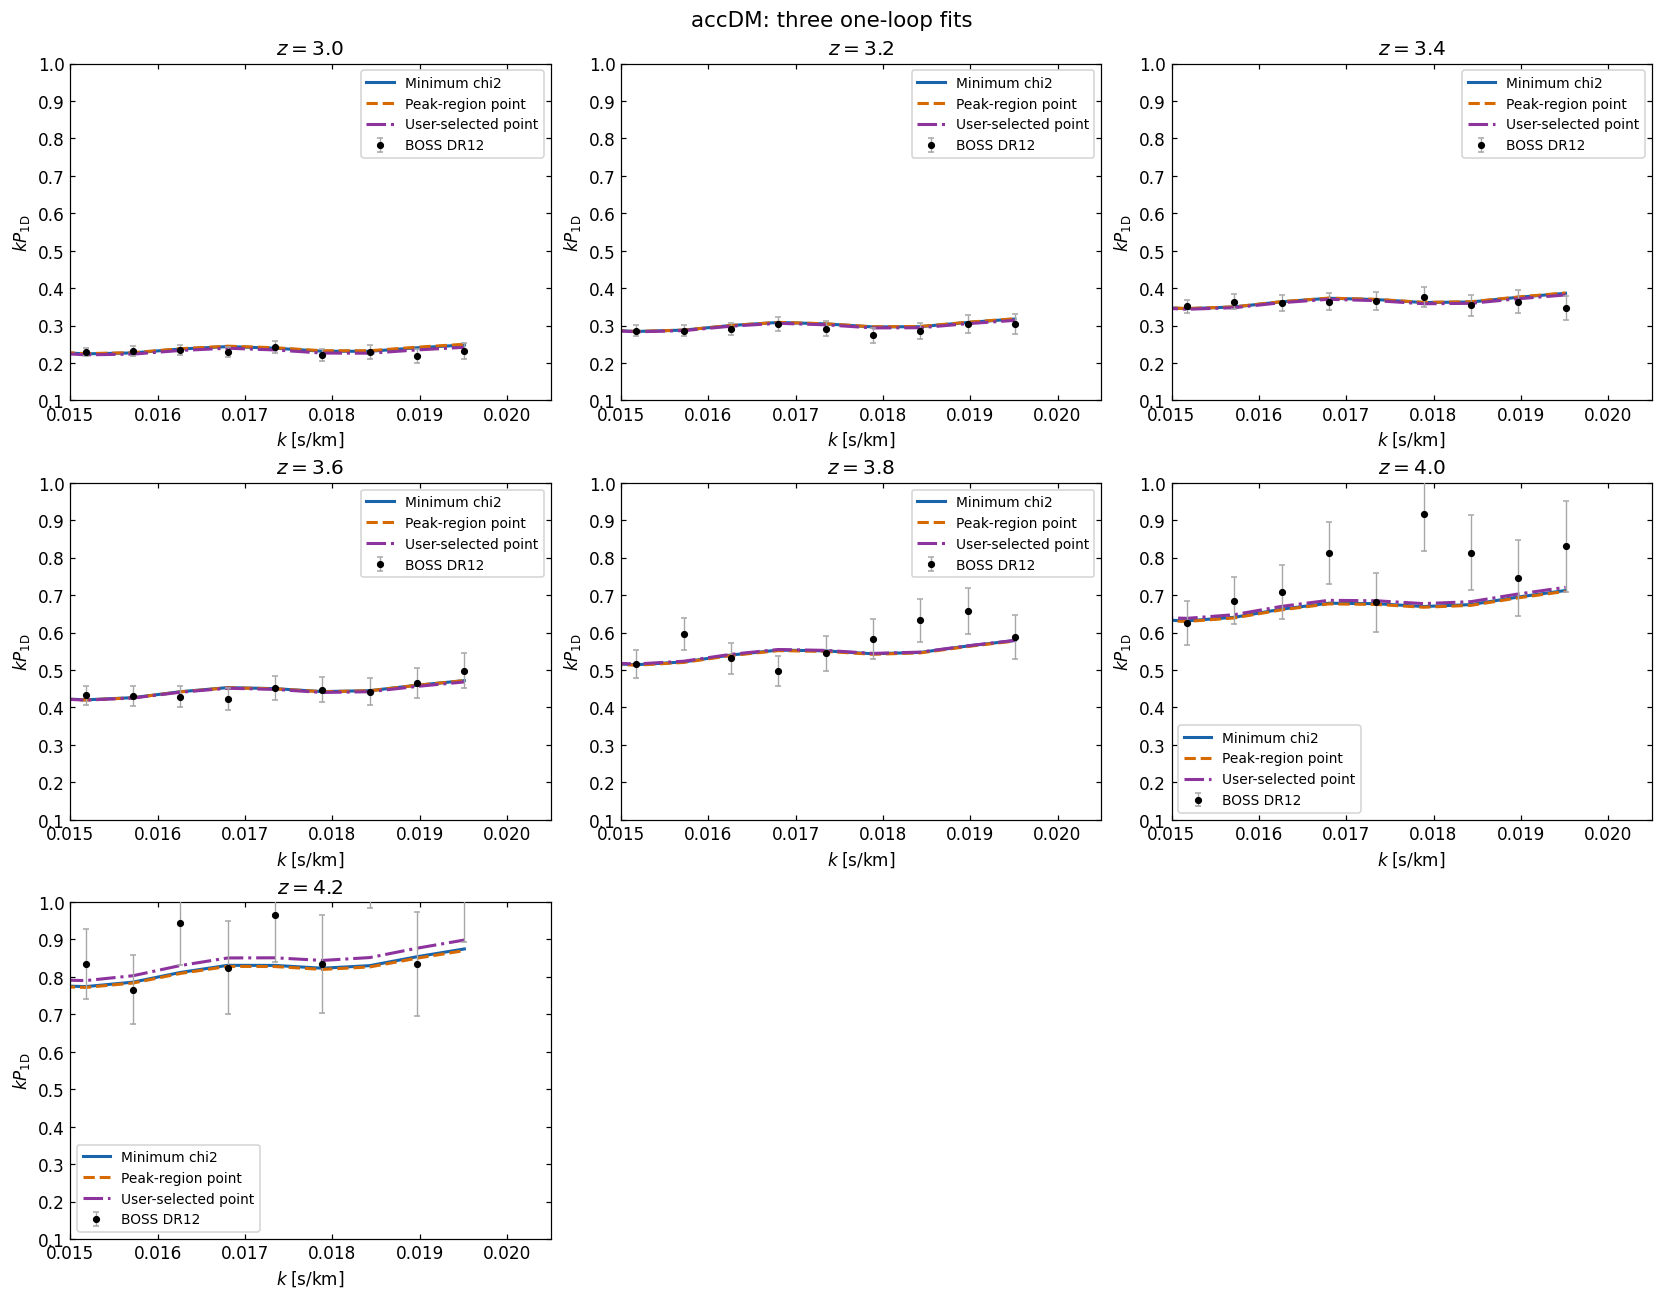

In [56]:
comparison = compare_three_points()
